Please note that in the functions reading_file and retreive_data you will need to replace the directory path with the corresponding path that you use personally on your own devices.

In [34]:
#importing necessary libraries
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import os

In [35]:
#terminate_program
""""
terminate_program

confirm_term = the user input in response to a prompt

This function works by taking a user input and checking to see if the input is 'esc', if not then it returns the Boolean
value of False so that the program will continue to run. Otherwise, it will return the Boolean value of True so that the
program will exit the while loop.
"""

def terminate_program(confirm_term):
    if confirm_term == '/':
        terminate = True
    else: 
        terminate = False
    return terminate

In [36]:
#reading_file
""""
reading_file

filename: the name of the file which is provided by the user

This function takes the file name and reads the first few lines of the file to get important information such as the
date and time of the experiement as well as the ns_channel value and channels_per_curve value. The function itself returns 
these values in a list in the following order: [date, time, channels_per_curve, ns_channel]
"""

def reading_file(path):
    file_info = open(path, "r")

    #defining a list that will contain the information of the experiment
    experiment_information = []

    #date of when the data was collected
    date_line = file_info.readline()
    date_of_experiment = date_line.split()[4]
    experiment_information.append(date_of_experiment)
    time_of_experiment = date_line.split()[5]
    experiment_information.append(time_of_experiment)

    print("")

    print("Date and Time of Experiment:", date_of_experiment, time_of_experiment)
    
    #file contains two important constants and the histogram data points
    file = np.loadtxt(path, unpack=True)

    #defining the important constants
    #length of the data (ie. the number of data points for this experiment; including data collected after experiment)
    channels_per_curve = file[0]
    experiment_information.append(channels_per_curve)
    ns_channel = file[3]
    experiment_information.append(ns_channel)
    
    print("channels_per_curve =", channels_per_curve)
    print("ns_channel =", ns_channel)

    #returns the list of information of the experiement
    return experiment_information

In [ ]:
#retrieve_data
""""
retrieve_data

filename = inputted filename which the program will retrieve the data from

This function works by taking a user input and using the given directory to find the filename and load the
data. The function will return an array of the data points.
"""

def retrieve_data(path):

    #file contains two important constants and the histogram data points
    file = np.loadtxt(path, unpack=True, skiprows = 10)

    #removing the "data" that was collected after the experiment ended
    data = np.trim_zeros(file) 

    return data

In [ ]:
#time_and_data_normalized

""""
time_and_data_normalized(exp_data, ns_channel)

exp_data = the array of data found from the retrieve_data function
ns_channel = the value taken from the reading_file

The time_and_data_normalized function determines the background data and subtracts it from the main data array which it then normalizes. It also
creates the time array in which we will use to plot all of our data. This function will return a 2D array in the 
form of [[time], [main_data_normalized]].
"""

def time_and_data_normalized(exp_data, bckgrd_data, ns_channel, duration_ratio):
    
    # averages those values
    bckgrd_data_avg = np.average(bckgrd_data)

    # multiplies the difference to get the correct average background count for the duration of experimental measurement duration
    bckgrd_data_avg = bckgrd_data_avg * duration_ratio

    exp_data = exp_data[:1800]

    max_index = np.argmax(exp_data) # finds the index of the maximum value of the experimental data array

    main_data = exp_data[max_index::] # defines the main data as starting from the max value to the end of the experimental data
    main_data_backgrd_subtracted = main_data - bckgrd_data_avg # subtracts the background from the main data
    main_data_normalized = main_data_backgrd_subtracted / np.max(main_data_backgrd_subtracted) #normalizing the main data


    time = np.arange(0, len(main_data_backgrd_subtracted) * ns_channel, ns_channel) # defining the time array

    experimental_array = [time, main_data_normalized] # 2D array of the time and main data
    return experimental_array

In [39]:
#define_parameters
"""
defining_fits

The defining_fits function's main goal is to return a list of the constants and time constants that will be used for the user's expenential fit.
It also does not take any input parameters. This function may be called multiple times if the user wishes to defined multiple exponential fits.
"""

def define_parameters():
    #determines the number of terms in the exponential fit
    num_of_terms = input("Please enter an integer between one and three for the number of terms you would like to include in your fit.")
    
    #checking to see if the user terminated the program
    terminate = terminate_program(num_of_terms)
    if terminate == True:
        return terminate
    
    num_of_terms = int(num_of_terms)
    parameters = []

    #executes a for loop to determine each of values for the set number of exponential terms
    for n in range(num_of_terms):
        term = n+1
        print("For your n = ", term," exponential term:")
        A = input("What would you like your A constant to be?")
        
        #checking to see if the user terminated the program
        terminate = terminate_program(A)
        if terminate == True:
            return terminate
        A = float(A)
        parameters.append(A)
        print("A",term,"=", A)
        tau = input("What would you like your tau constant to be?")
        terminate = terminate_program(num_of_terms)

        #checking to see if the user terminated the program
        if terminate == True:
            return terminate
        tau = float(tau)
        parameters.append(tau)
        print("Tau",term,"=",tau)

    #creates the list of the int of the number of terms and their given parameters - the num_of_terms will be used later when plotting the data
    exp_fit_info = [num_of_terms, parameters]
    return exp_fit_info

In [40]:
#data_analysis
"""
safe_exp

value = the value of the exponential of a varying time and constant tau value

Since we are using exponential decay functions we know that at certain values close to zero they approach zero. This function simply trims values that
are near that region so that the fits don't obstruct our ability to see the decay of the data that we are interested in.

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

exponential

t = time array
A1 = constant in front of the first exponential term
tau1 = time constant for the first exponential term

This function returns the fit function corresponding to the one term exponential fit. It does so by returning a function that does call the safe_exp
function to avoid the problem mentioned in the safe_exp description.

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

biexponential

t = time array
A1 = constant in front of the first exponential term
tau1 = time constant for the first exponential term
A2 = constant in front of the second exponential term
tau2 = time constant for the second exponential term

This function returns the fit function corresponding to the two term exponential fit. It does so by returning a function that does call the safe_exp
function to avoid the problem mentioned in the safe_exp description.

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

triexponential

t = time array
A1 = constant in front of the first exponential term
tau1 = time constant for the first exponential term
A2 = constant in front of the second exponential term
tau2 = time constant for the second exponential term
A3 = constant in front of the third exponential term
tau3 = time constant for the third exponential term

This function returns the fit function corresponding to the three term exponential fit. It does so by returning a function that does call the safe_exp
function to avoid the problem mentioned in the safe_exp description.
"""

# Define Safe Exponential Function to Avoid Overflow
def safe_exp(value):
    return np.exp(np.clip(value, -700, 0))

# Define Exponential Model
def exponential(t, A1, tau1):
    return A1 * safe_exp(-t/tau1)

# Define Biexponential Model
def biexponential(t, A1, tau1, A2, tau2):
    return A1 * safe_exp(-t / tau1) + A2 * safe_exp(-t / tau2)

# Define Triexponential Model
def triexponential(t, A1, tau1, A2, tau2, A3, tau3):
    return A1 * safe_exp(-t / tau1) + A2 * safe_exp(-t / tau2) + A3 * safe_exp(-t / tau3)

"""
data_analysis

num_of_exponentials = the number of terms in the fit
data = normalized data array that
time = time array
guesses = a list of integers corresponding to the constants and time constants in the form [A1, tau1, A2, tau2, A3, tau3]

The data_analysis function returns a fit of the data from a given exponential fit  and the corresponding residuals that is inputted by the user. It does so by first determining how
many exponential terms are in the fit then executing the following process:
    1. Trim any zeros from the guesses list so that we do not encounter any divide by zeros errors (this is dependent on how many exponential terms there
    are)
    2. Then it will execute a curve_fit which calls a function to define the fit being used (exponential, biexponential, triexponential functions) which
    return the corresponding function for the fit
    3. Then it defines the actual constants (A1, tau1, A2, tau2, A3, tau3) and their errors (which is found from the diagonals of the pcov_exp matrix)
    4. Then it normalizes the fit
    5. Makes a list of the actual constants and their errors
    6. Determines the residuals
    7. Makes a 2D array of the actual constants, normalized fit, and residuals
    8. Returns the above 2D array
"""

def data_analysis(num_of_exponentials, data, time, guesses):
    if num_of_exponentials == 1: # one term exponential fit
        guesses = np.trim_zeros(guesses) #reduces guesses list to constants important to the fit
        popt_exp, pcov_exp = curve_fit(exponential, time, data, p0=guesses, maxfev=2000) #fitting the data to the model
        A1_exp, tau1_exp = popt_exp #defining the "new.updated" constants
        errors_exp = np.sqrt(np.diag(pcov_exp)) #determining the errors from the diagonal of the matrix
        fit_exp_normalized = exponential(time, *popt_exp) / np.max(data) #normalizing the fit
        parameters = [A1_exp, tau1_exp, errors_exp] #list of the parameter information
        residual1 = data - fit_exp_normalized #determining the residuals

        exp_fit_model = [num_of_exponentials, parameters, fit_exp_normalized, residual1] #2D list of the parameter information and the normalized fit
        return exp_fit_model

    elif num_of_exponentials == 2: # two term exponential fit
        guesses = np.trim_zeros(guesses) #reduces guesses list to constants important to the fit
        popt_bi, pcov_bi = curve_fit(biexponential, time, data, p0=guesses, maxfev=2000) #fitting the data to the model
        A1_bi, tau1_bi, A2_bi, tau2_bi = popt_bi #defining the "new/updated" constants
        errors_bi = np.sqrt(np.diag(pcov_bi)) #determining the errors from the diagonal of the matrix
        fit_bi_normalized = biexponential(time, *popt_bi) / np.max(data) #normalizing the fit
        parameters = [A1_bi, tau1_bi, A2_bi, tau2_bi, errors_bi] #list of the parameter information
        residual2 = data - fit_bi_normalized #determining the residuals

        bi_fit_model = [num_of_exponentials, parameters, fit_bi_normalized, residual2] #2D list of the parameter information and the normalized fit
        return bi_fit_model

    else: # three term exponential fit
        popt_tri, pcov_tri = curve_fit(triexponential, time, data, p0=guesses, maxfev=2000) #fitting the data to the model
        A1_tri, tau1_tri, A2_tri, tau2_tri, A3_tri, tau3_tri = popt_tri #defining the "new/updated" constants
        errors_tri = np.sqrt(np.diag(pcov_tri)) #determining the errors from the diagonal of the matrix
        fit_tri_normalized = triexponential(time, *popt_tri) / np.max(data) #normalizing the fit
        parameters = [A1_tri, tau1_tri, A2_tri, tau2_tri, A3_tri, tau3_tri, errors_tri] #list of the parameter information
        residual3 = data - fit_tri_normalized #determining the residuals

        tri_fit_model = [num_of_exponentials, parameters, fit_tri_normalized, residual3] #2D list of the parameter information and the normalized fit
        return tri_fit_model

In [41]:
#determine_residuals
"""
determine_residuals

data = normalized main data array
fit_data = normalized data array of the fit

This function determines the residuals by simply subtracting the normalized data array from normalzied main data array and then returns this new residual
data array.
"""

def determine_residuals(data, fit_data):
    residuals = data - fit_data #subtraction of the main data and fitted data
    return residuals

In [42]:
#plotting
""""
plots

num_of_termss = the number of terms for the inputted fit
time_array = time array
main_data = normalized main data array
fitted_data = fitted data for a given fit determined by the user
residuals = subtraction of the main data and fitted data

The plots function aims to plot each fit and its respective residuals for the normalized main data set without returning anything. Based on the number of 
exponentials in the fit the program will change the name and color of the plot of the fitted data. Meanwhile, the normalized main data will always be 
assigned the color black along with the respective residuals. 
"""

def plots(num_of_terms, time_array, main_data, fitted_data, residuals):
    # determing the color and respective names for each plot based on the number of terms in each exponential
    if num_of_terms == 1:
        fit_color = 'blue'
        fit_label = 'Exponential Fit'
        mosaic_title = 'Exponential Fit of Flourescence Decay Data and Residuals' # determines the title of the overall figure
        subtitle = 'Exponential Fit of Flourescence Decay Data'
    elif num_of_terms == 2:
        fit_color = 'green'
        fit_label = 'Bi-Exponential Fit' 
        mosaic_title = 'Bi-Exponential Fit of Flourescence Decay Data and Residuals' # determines the title of the overall figure
        subtitle = 'Bi-Exponential Fit of Flourescence Decay Data'
    else:
        fit_color = 'red'
        fit_label = 'Tri-Exponential Fit' 
        mosaic_title = 'Tri-Exponential Fit of Flourescence Decay Data and Residuals' # determines the title of the overall figure
        subtitle = 'Tri-Exponential Fit of Flourescence Decay Data' # determines the name of the plot of the fitted data and main data vs. time

    # plotting the two plots - upper is the fitted data and main data vs. time, lower - residuals plot
    gs_kw = dict(height_ratios=[2,1]) # determines the height ratio s.t. the residuals are below and smaller than the upper plot
    fig, axd = plt.subplot_mosaic([['upper'],
                               ['lower']],
                              gridspec_kw=gs_kw, figsize=(12, 6),
                              layout="constrained")
    # plotting the upper plot
    axd['upper'].plot(time_array, main_data, color = 'black', label = 'Normalized Data')
    axd['upper'].plot(time_array, fitted_data, color = f"{fit_color}", linestyle = '--', label = f"{fit_label}")
    axd['upper'].legend()
    axd['upper'].set_yscale("log")
    axd['upper'].set_xlabel("Delay Time (ns)")
    axd['upper'].set_ylabel("Normalized PL (a.u.)")
    axd['upper'].set_title(f"{subtitle}")

    # plotting the lower plot
    axd['lower'].plot(time_array, residuals, color = 'black')
    axd['lower'].set_xlabel("Delay Time (ns)")
    axd['lower'].set_ylabel("Residuals")
    axd['lower'].set_title("Residuals Plot of Flourescence Decay Data")

    # name of the overall figure
    fig.suptitle(f"{mosaic_title}")


In [43]:
#comparison_plot
"""
comparison_plot

num_of_fits = the number of fits the program will plot for comparison
time_array = time_array
main_data = normalized main data
fit1 = fitted data for the first fit
num_exp_fit1 = number of terms in the first fit
fit2 = fitted data for the second fit
num_exp_fit2 = number of terms in the second fit
fit3 = fitted data for the third fit
num_exp_fit3 = number of terms in the third fit

The comparison_plot function aims to plot all of the fits the user determined with the normalized main data all on one graph so that the user can compare
each fit against one another. It first determines whether or not there are two or three fits to compare then assigns the proper label for each fit. After
it assigns all the correct labels it will plot each of the fits. If there is only one fit then the function will not plot anything and will return.
"""


def comparison_plot(num_of_fits, time_array, main_data, num_exp_fit1, fit1, num_exp_fit2, fit2, num_exp_fit3, fit3):

    # for two fits
    if num_of_fits == 2:
        # using a for loop to determine the correct labels for each fit
        kind_of_fit = [num_exp_fit1, num_exp_fit2]
        for n in range(len(kind_of_fit)):
            if kind_of_fit[n] == 1:
                kind_of_fit[n] = 'Exponential Fit'
            elif kind_of_fit[n] == 2:
                kind_of_fit[n] = 'Bi-Exponential Fit'
            else:
                kind_of_fit[n] = 'Tri-Exponential Fit'

        fit1_label = kind_of_fit[0]
        fit2_label = kind_of_fit[1]

        # plotting the comparison plot
        fig4, comparison_plot = plt.subplots(figsize = (12,6))

        comparison_plot.plot(time_array, main_data, color = 'black', label = 'Normalized Data')
        comparison_plot.plot(time_array, fit1, color = 'blue', linestyle = '--', label = f"{fit1_label}")
        comparison_plot.plot(time_array, fit2, color = 'green', linestyle = '--', label = f"{fit2_label}")
        comparison_plot.set_yscale("log")
        comparison_plot.legend()
        comparison_plot.set_xlabel("Delay Time (ns)")
        comparison_plot.set_ylabel("Normalized PL (a.u.)")
        comparison_plot.set_title("Comparison of Fits for Flourescence Decay Data")

    # for three fits
    elif num_of_fits == 3:
        # using a for loop to determine the correct labels for each fit
        kind_of_fit = [num_exp_fit1, num_exp_fit2, num_exp_fit3]
        for n in range(len(kind_of_fit)):
            if kind_of_fit[n] == 1:
                kind_of_fit[n] = 'Exponential Fit'
            elif kind_of_fit[n] == 2:
                kind_of_fit[n] = 'Bi-Exponential Fit'
            else:
                kind_of_fit[n] = 'Tri-Exponential Fit'

        fit1_label = kind_of_fit[0]
        fit2_label = kind_of_fit[1] 
        fit3_label = kind_of_fit[2]  

        # plotting the comparison plot
        fig, comparison_plot = plt.subplots(figsize = (12,6))

        comparison_plot.plot(time_array, main_data, color = 'black', label = 'Normalized Main Data')
        comparison_plot.plot(time_array, fit1, color = 'blue', linestyle = '--', label = f"{fit1_label}")
        comparison_plot.plot(time_array, fit2, color = 'green', linestyle = '--', label = f"{fit2_label}")
        comparison_plot.plot(time_array, fit3, color = 'red', linestyle = '--', label = f"{fit3_label}")
        comparison_plot.set_yscale("log")
        comparison_plot.legend()
        comparison_plot.set_xlabel("Delay Time (ns)")
        comparison_plot.set_ylabel("Normalized PL (a.u.)")
        comparison_plot.set_title("Comparison of Fits for Flourescence Decay Data")

    # special case where there is only one fit
    else:
        return

To terminate this program press '/'.

Date and Time of Experiment: 06/18/2025 12:43:17
channels_per_curve = 65536.0
ns_channel = 0.512

Set Guesses:

Exponential Fit:
A1 = 500, τ1 = 100

Bi-exponential Fit:
A1 = 500, τ1 = 100, A2 = 50, τ2 = 10

Tri-exponential Fit:
A1 = 500, τ1 = 100, A2 = 50, τ2 = 10, A3 = 20, τ3 = 5

Please input either Y or N.

Exponential Fit Time Decay Constant:
τ1 = 40.351387975676765 ± 0.21 ns

Bi-Exponential Fit Time Decay Constants:
τ1 = 87.79554842276859 ± 1.67 ns
τ2 = 24.299102158503842 ± 0.32 ns

Tri-Exponential Fit Decay Constants:
τ1 = 120.71196694401844 ± 3.30 ns
τ2 = 3.2133396202075954 ± 0.21 ns
τ3 = 31.862144347451466 ± 0.41 ns

The program has terminated.


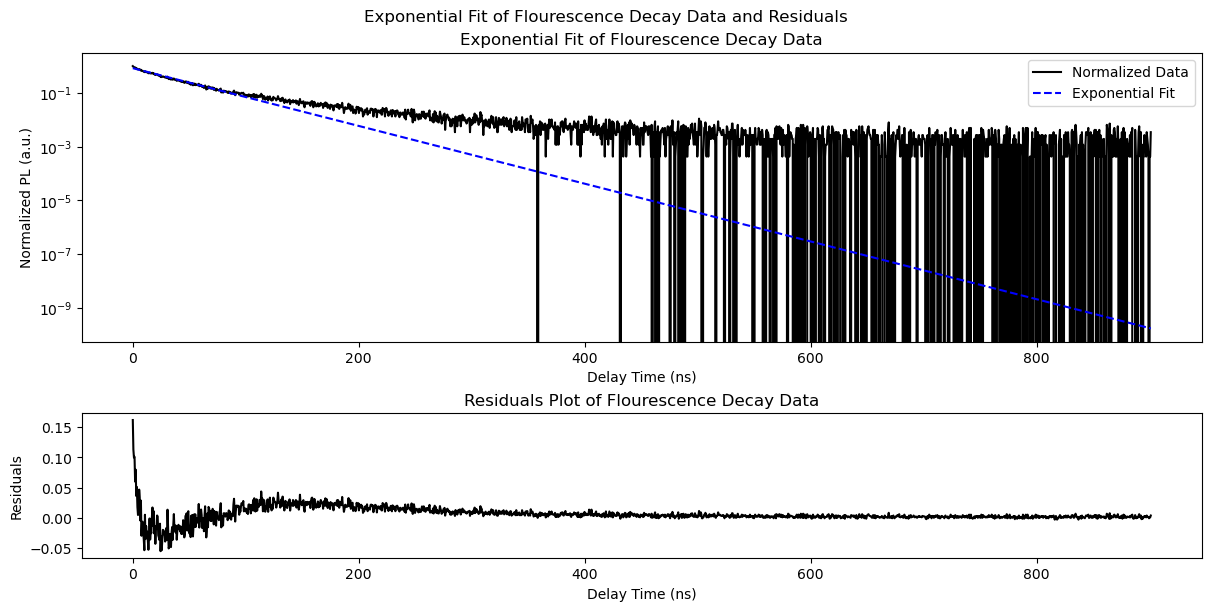

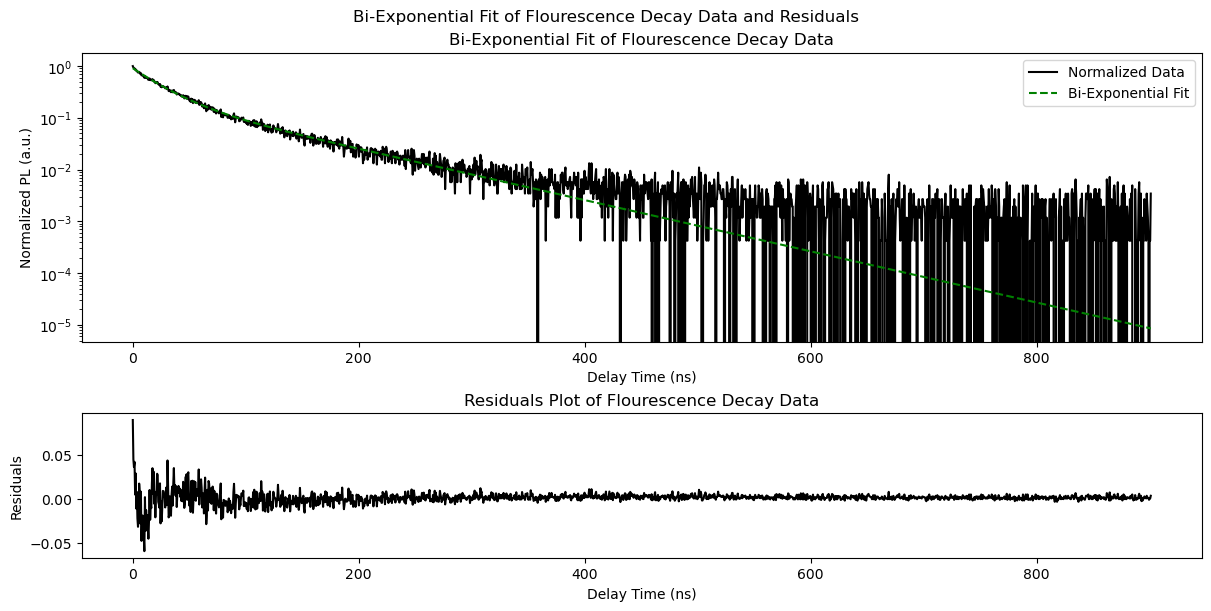

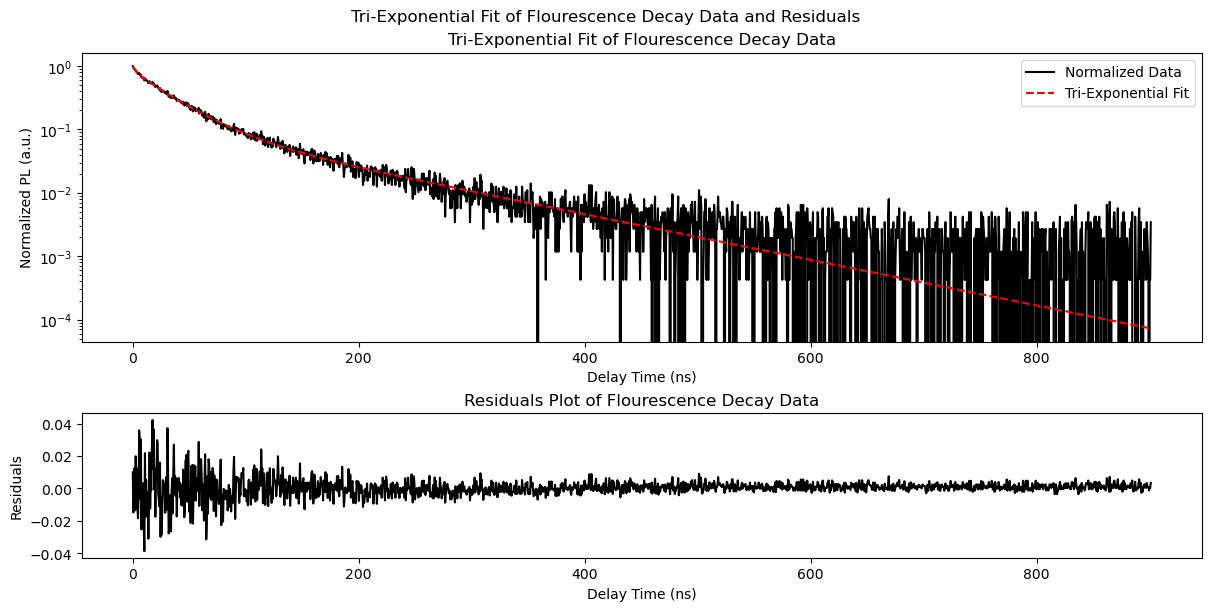

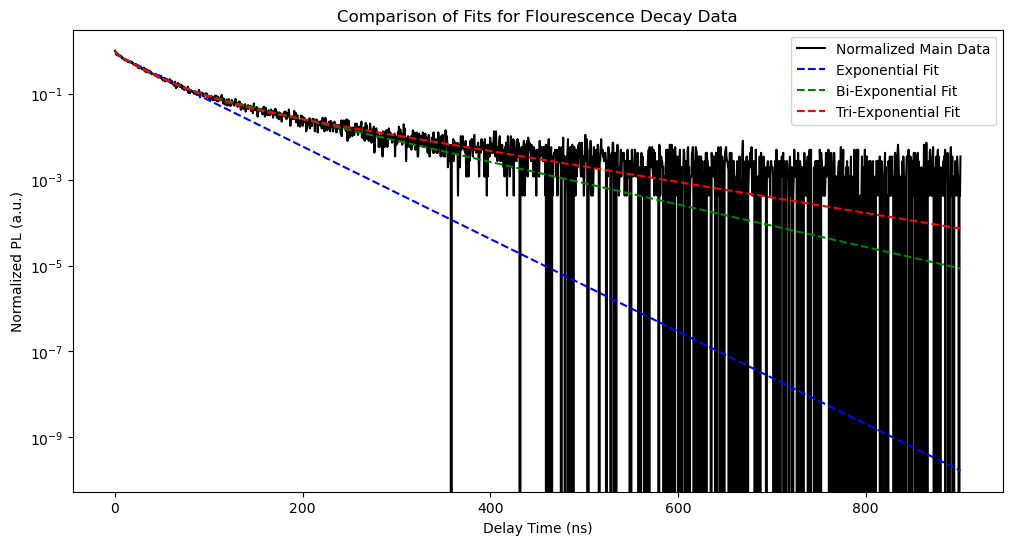

In [44]:
""""
Main Program:
The program executes in a while loop that will terminate whenever the user inputs '/'. The code itself is split into three different sections:
    1. Reading in the file and retriving the data
    2. The data analysis; this includes things like determining the background data and normalizing the main data, etc. 
    3. Plotting the data (main data, residuals, exponential fits)

Note: The retrieve_data function is the one that will need to be optimized for the T3 data.
"""

if __name__ == '__main__':
    # to terminate press /
    print("To terminate this program press '/'.")

    # while loop that will keep the program running until the user wishes to terminate the program
    
    terminate = False
    while terminate == False:
        
        # if you want you can directly paste in the file name here and comment out the input line
        measurement_path = r"/Users/jadenchilimigras/Downloads/Research/Pelton/T2_Data/06_18_2025/T2_for_CdSe_CdS_06_18_2025_62.5kHz_512ps_120sec.dat"
        #measurement_path = input("Please provide the path of your experimental file:") # the filename will be used to 
        
        terminate = terminate_program(measurement_path) # checking to see if the user wants to terminate the program
        if terminate == True: # terminates the program
            break

        experiment_info = reading_file(measurement_path) # retriving a list of the date, time, ns_channel, and channels per curve

        ns_channel = experiment_info[3] # defining the ns_channel parameter from the experiment_info list

        print("")

        background_path = r"/Users/jadenchilimigras/Downloads/Research/Pelton/T2_Data/06_18_2025/T2_for_background_06_18_2025_62.5kHz_512ps_120sec.dat"
        #background_path = input("Please provide the name of your background file:")

        terminate = terminate_program(background_path) # checking to see if the user wants to terminate the program
        if terminate == True: # terminates the program
            break

        exp_duration = input("Please provide the duration of your experiment as a number in minutes:") # time of experimental measurement

        terminate = terminate_program(exp_duration) # checking to see if the user wants to terminate the program
        if terminate == True: # terminates the program
            break

        exp_duration = float(exp_duration) * 60 # converts the value into seconds

        bckgrd_duration = input("Please provide the duration of your background measurement as a number in minutes:") # time of background measurement

        terminate = terminate_program(bckgrd_duration) # checking to see if the user wants to terminate the program
        if terminate == True: # terminates the program
            break

        bckgrd_duration = float(bckgrd_duration) * 60 # converts the value into seconds

        duration_ratio = exp_duration / bckgrd_duration # finds the ratio between the two durations

        experiment_data = retrieve_data(measurement_path) # retrives the experimental data as a np.darray from the file
        background_data = retrieve_data(background_path) # retrieves the background data as a np.darray from the file

        time_and_normalized_main_data = time_and_data_normalized(experiment_data, background_data, ns_channel, duration_ratio) # 2D array [[time array], [normalized main data]]

        # defining each array
        time_array = time_and_normalized_main_data[0]
        normalized_main_data_array = time_and_normalized_main_data[1]

        # prints out the set guesses if the user does not wish to define their own

        print("Set Guesses:")
        print("")

        print("Exponential Fit:")
        print("A1 = 500, τ1 = 100")

        print("")

        print("Bi-exponential Fit:")
        print("A1 = 500, τ1 = 100, A2 = 50, τ2 = 10")

        print("")

        print("Tri-exponential Fit:")
        print("A1 = 500, τ1 = 100, A2 = 50, τ2 = 10, A3 = 20, τ3 = 5")

        print("")

        print("Please input either Y or N.")

        # prompts the user to tell the program whether or not they wish to define their own fits
        # if not the program uses a while loop s.t. it won't crash if the user does not give a correct input

        valid = False
        while valid == False:
            path = input("Would you like to use the set guesses for your exponential fits?")
            path = path.upper()
            if path == 'Y':
                break
            elif path == 'N':
                break
            else:
                print("You did not enter a valid input.")

        #if the user wishes to use the set guess the program will follow this path

        if path == 'Y':
            # in the form A1, tau1, A2, tau2, A3, tau3
            set_guesses_exp = [500, 100, 0, 0, 0, 0]
            set_guesses_bi = [500, 100, 50, 10, 0, 0]
            set_guesses_tri = [500, 100, 50, 10, 20, 5]

            # defining the fit models in the form: 
            # [number of parameters, 2D array of parameter values and their errors, the normalized fit, residuals]

            set_fit1_model = data_analysis(1, normalized_main_data_array, time_array, set_guesses_exp)
            set_fit2_model = data_analysis(2, normalized_main_data_array, time_array, set_guesses_bi)
            set_fit3_model = data_analysis(3, normalized_main_data_array, time_array, set_guesses_tri)

            # printing the time constants for each of the fits

            print("")

            plots(set_fit1_model[0], time_array, normalized_main_data_array, set_fit1_model[2], set_fit1_model[3])

            print("Exponential Fit Time Decay Constant:")
            print(f"τ1 = {set_fit1_model[1][1]} ± {set_fit1_model[1][2][1]:.2f} ns")

            print("")

            plots(set_fit2_model[0], time_array, normalized_main_data_array, set_fit2_model[2], set_fit2_model[3])

            print("Bi-Exponential Fit Time Decay Constants:")
            print(f"τ1 = {set_fit2_model[1][1]} ± {set_fit2_model[1][4][1]:.2f} ns")
            print(f"τ2 = {set_fit2_model[1][3]} ± {set_fit2_model[1][4][3]:.2f} ns")

            print("")

            plots(set_fit3_model[0], time_array, normalized_main_data_array, set_fit3_model[2], set_fit3_model[3])

            print("Tri-Exponential Fit Decay Constants:")
            print(f"τ1 = {set_fit3_model[1][1]} ± {set_fit3_model[1][6][1]:.2f} ns")
            print(f"τ2 = {set_fit3_model[1][3]} ± {set_fit3_model[1][6][3]:.2f} ns")
            print(f"τ3 = {set_fit3_model[1][5]} ± {set_fit3_model[1][6][5]:.2f} ns")

            print("")

            # makes the comparison of the fits plot
            comparison_plot(3, time_array, normalized_main_data_array, 1, set_fit1_model[2], 2, set_fit2_model[2], 3, set_fit3_model[2])
            
        # if the user wishes to define their own guesses the program will follow this path

        elif path == 'N':
            # determines how many fits the user would like to plot (works for 1-3 fits)
            num_of_fits = int(input("How many exponential fits would you like to plot?"))
            terminate = terminate_program(num_of_fits)
            if terminate == True:
                break

            fits_parameters = []

            # determines the parameters for each fit
            for n in range(num_of_fits):
                term = n + 1
                print("For your n =", term,"exponential fit:")
                parameters = define_parameters()
                if parameters == True:
                    break
                fits_parameters.append(parameters)

            fitted_models = []

            # gets the fitted models for each of the fits determined by the user
            for n in range(num_of_fits):
                fit_model = data_analysis(fits_parameters[n][0], normalized_main_data_array, time_array, fits_parameters[n][1])
                plots(fit_model[0], time_array, normalized_main_data_array, fit_model[2], fit_model[3])
                fitted_models.append(fit_model)

            # printing the time constants for the respective number of fits that have been made
            # if there is more than one exponential fit the program will also plot a comparison plot of the fits

            # only one exponential fit
            if num_of_fits == 1:
                fit1 = fitted_models[0]
                fit1_data = fit1[2]

                if fit1[0] == 1:
                    print("Exponential Fit Decay Constants:")
                    print(f"τ1 = {fit1[1][1]} ± {fit1[1][2][1]:.2f} ns")
                elif fit1[0] == 2:
                    print("Biexponential Fit Decay Constants")
                    print(f"τ1 = {fit1[1][1]} ± {fit1[1][4][1]:.2f} ns")
                    print(f"τ2 = {fit1[1][3]} ± {fit1[1][4][3]:.2f} ns")
                else:
                    print("Triexponential Fit Decay Constants")
                    print(f"τ1 = {fit1[1][1]} ± {fit1[1][6][1]:.2f} ns")
                    print(f"τ2 = {fit1[1][4]} ± {fit1[1][6][3]:.2f} ns")
                    print(f"τ3 = {fit1[1][5]} ± {fit1[1][6][5]:.2f} ns")

            # two exponential fits
            elif num_of_fits == 2:
                fit1 = fitted_models[0]
                fit1_data = fit1[2]
                fit1_num_of_exp = fit1[0]

                if fit1[0] == 1:
                    print("Exponential Fit Decay Constants:")
                    print(f"τ1 = {fit1[1][1]} ± {fit1[1][2][1]:.2f} ns")
                elif fit1[0] == 2:
                    print("Biexponential Fit Decay Constants")
                    print(f"τ1 = {fit1[1][1]} ± {fit1[1][4][1]:.2f} ns")
                    print(f"τ2 = {fit1[1][3]} ± {fit1[1][4][3]:.2f} ns")
                else:
                    print("Triexponential Fit Decay Constants")
                    print(f"τ1 = {fit1[1][1]} ± {fit1[1][6][1]:.2f} ns")
                    print(f"τ2 = {fit1[1][4]} ± {fit1[1][6][3]:.2f} ns")
                    print(f"τ3 = {fit1[1][5]} ± {fit1[1][6][5]:.2f} ns")

                fit2 = fitted_models[1]
                fit2_data = fit2[2]
                fit2_num_of_exp = fit2[0]

                if fit2[0] == 1:
                    print("Exponential Fit Decay Constants:")
                    print(f"τ1 = {fit2[1][1]} ± {fit2[1][2][1]:.2f} ns")
                elif fit2[0] == 2:
                    print("Biexponential Fit Decay Constants")
                    print(f"τ1 = {fit2[1][1]} ± {fit2[1][4][1]:.2f} ns")
                    print(f"τ2 = {fit2[1][3]} ± {fit2[1][4][3]:.2f} ns")
                else:
                    print("Triexponential Fit Decay Constants")
                    print(f"τ1 = {fit2[1][1]} ± {fit2[1][6][1]:.2f} ns")
                    print(f"τ2 = {fit2[1][4]} ± {fit2[1][6][3]:.2f} ns")
                    print(f"τ3 = {fit2[1][5]} ± {fit2[1][6][5]:.2f} ns")

                # plotting a comparison plot
                comparison_plot(num_of_fits, time_array, normalized_main_data_array, fit1_num_of_exp, fit1_data, fit2_num_of_exp, fit2_data, 0, 0)

            # three exponential fits
            elif num_of_fits == 3:
                fit1 = fitted_models[0]
                fit1_data = fit1[2]
                fit1_num_of_exp = fit1[0]

                if fit1[0] == 1:
                    print("Exponential Fit Decay Constants:")
                    print(f"τ1 = {fit1[1][1]} ± {fit1[1][2][1]:.2f} ns")
                elif fit1[0] == 2:
                    print("Biexponential Fit Decay Constants")
                    print(f"τ1 = {fit1[1][1]} ± {fit1[1][4][1]:.2f} ns")
                    print(f"τ2 = {fit1[1][3]} ± {fit1[1][4][3]:.2f} ns")
                else:
                    print("Triexponential Fit Decay Constants")
                    print(f"τ1 = {fit1[1][1]} ± {fit1[1][6][1]:.2f} ns")
                    print(f"τ2 = {fit1[1][4]} ± {fit1[1][6][3]:.2f} ns")
                    print(f"τ3 = {fit1[1][5]} ± {fit1[1][6][5]:.2f} ns")

                fit2 = fitted_models[1]
                fit2_data = fit2[2]
                fit2_num_of_exp = fit2[0]

                if fit2[0] == 1:
                    print("Exponential Fit Decay Constants:")
                    print(f"τ1 = {fit2[1][1]} ± {fit2[1][2][1]:.2f} ns")
                elif fit2[0] == 2:
                    print("Biexponential Fit Decay Constants")
                    print(f"τ1 = {fit2[1][1]} ± {fit2[1][4][1]:.2f} ns")
                    print(f"τ2 = {fit2[1][3]} ± {fit2[1][4][3]:.2f} ns")
                else:
                    print("Triexponential Fit Decay Constants")
                    print(f"τ1 = {fit2[1][1]} ± {fit2[1][6][1]:.2f} ns")
                    print(f"τ2 = {fit2[1][4]} ± {fit2[1][6][3]:.2f} ns")
                    print(f"τ3 = {fit2[1][5]} ± {fit2[1][6][5]:.2f} ns")

                fit3 = fitted_models[2]
                fit3_data = fit3[2]
                fit3_num_of_exp = fit3[0]

                if fit3[0] == 1:
                    print("Exponential Fit Decay Constants:")
                    print(f"τ1 = {fit3[1][1]} ± {fit3[1][2][1]:.2f} ns")
                elif fit3[0] == 2:
                    print("Biexponential Fit Decay Constants")
                    print(f"τ1 = {fit3[1][1]} ± {fit3[1][4][1]:.2f} ns")
                    print(f"τ2 = {fit3[1][3]} ± {fit3[1][4][3]:.2f} ns")
                else:
                    print("Triexponential Fit Decay Constants")
                    print(f"τ1 = {fit3[1][1]} ± {fit3[1][6][1]:.2f} ns")
                    print(f"τ2 = {fit3[1][4]} ± {fit3[1][6][3]:.2f} ns")
                    print(f"τ3 = {fit3[1][5]} ± {fit3[1][6][5]:.2f} ns")
            
                # plotting a comparison plot
                comparison_plot(num_of_fits, time_array, normalized_main_data_array, fit1[0], fit1_data, fit2[0], fit2_data, fit3[0], fit3_data)


        # makes sure the program will terminate after it runs through all the code
        terminate = True

    print("The program has terminated.")